Model Notebook

This is the notebook for model in age gender detector. Here, we will extract the data
, train it and fit into our model, and will evaluate our results and optimize for better results

Import The Necessary Libraries

In [1]:
import tensorflow as tf
import cv2
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.layers import Dropout
from tensorflow.keras. layers import Flatten
from tensorflow.keras.layers import BatchNormalization
#Relace MaxPool2D with MaxPooling2D
from tensorflow.keras.layers import Dense, MaxPool2D, Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Activation, Add
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, Adagrad, Adadelta, Adamax, RMSprop

Extract data from the dataset

If data has not been downloaded yet, download it from [Here](https://www.kaggle.com/datasets/jangedoo/utkface-new)

In [2]:
folder = "./UTKFace"

In [3]:
import os
files = os.listdir(folder)

##Create list of images from the dataset

In [4]:
ages = []
genders = []
images = []

for fle in files:
    age =  int(fle.split('_')[0])
    gender = int(fle.split('_')[1])
    total = folder+'/'+fle
    print(total)
    image = cv2.imread(total)

    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    image = cv2.resize(image,(48,48))
    images.append(image)

./UTKFace/100_0_0_20170112213500903.jpg.chip.jpg
./UTKFace/100_0_0_20170112215240346.jpg.chip.jpg
./UTKFace/100_1_0_20170110183726390.jpg.chip.jpg
./UTKFace/100_1_0_20170112213001988.jpg.chip.jpg
./UTKFace/100_1_0_20170112213303693.jpg.chip.jpg
./UTKFace/100_1_0_20170112215032192.jpg.chip.jpg
./UTKFace/100_1_0_20170117195420803.jpg.chip.jpg
./UTKFace/100_1_0_20170119212053665.jpg.chip.jpg
./UTKFace/100_1_2_20170105174847679.jpg.chip.jpg
./UTKFace/100_1_2_20170112213615815.jpg.chip.jpg
./UTKFace/100_1_2_20170112222336458.jpg.chip.jpg
./UTKFace/101_0_0_20170112213500903.jpg.chip.jpg
./UTKFace/101_1_2_20170105174739309.jpg.chip.jpg
./UTKFace/103_0_2_20170112213001988.jpg.chip.jpg
./UTKFace/105_0_0_20170112213001988.jpg.chip.jpg
./UTKFace/105_1_0_20170112213001988.jpg.chip.jpg
./UTKFace/105_1_0_20170112213021902.jpg.chip.jpg
./UTKFace/105_1_0_20170112213507183.jpg.chip.jpg
./UTKFace/105_1_1_20170112213303693.jpg.chip.jpg
./UTKFace/10_0_0_20161220222308131.jpg.chip.jpg
./UTKFace/10_0_0_2017

##Create list of Age and Gender from the dataset

In [5]:
for fle in files:
    age = int(fle.split('_')[0])
    gender = int(fle.split('_')[1])
    ages.append(age)
    genders.append(gender)
    
    

Viewing a Sample

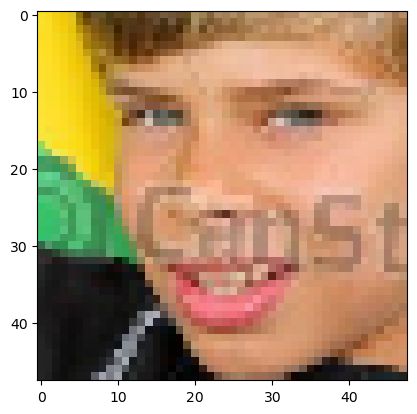

In [6]:
plt.imshow(images[45])

In [7]:
print(ages[87])

10


In [8]:
#0 for male gender and 1 for female gender
print(genders[87])

0


##Saving images array, ages array and genders array in the system

In [9]:
images_f = np.array(images)
ages_f = np.array(ages)
genders_f = np.array(genders)

In [10]:
np.save(folder+'image.npy',images_f)
np.save(folder+'ages.npy',ages_f)
np.save(folder+'genders.npy',genders_f)

##Finding the no. of elements in the dataset 

In [11]:
#[number of male images , number of female images]
values,counts = np.unique(genders_f,return_counts = True)
print(counts)

[12391 11317]


Plotting the number of Male and Female samples

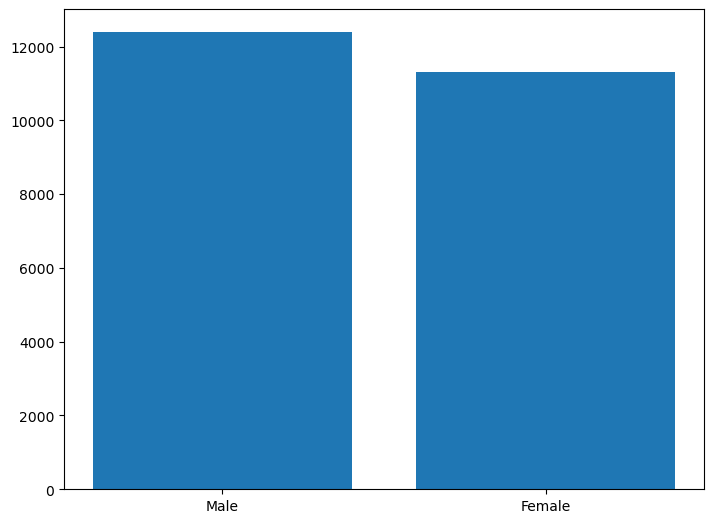

In [12]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
gender = ['Male','Female']
values = [12391,11317]
ax.bar(gender,values)
plt.show()

Finding the no ofsamples in each age

In [13]:
#No of samples of every age
values, counts = np.unique(ages_f,return_counts=True)
print(counts)

[1123  482  289  273  196  131  139  263  166  156   65  130   81  157
  177  247  158  262   98  284  346  395  426  859  734 2197  615  918
  570  724  350  664  143  409  880  483  293  325  266  526  132  266
  157  100  440  153  170  153  148  381  138  232  241  353  268  236
   97  271   82  293  161  125  103   50  259   77   94  100   56  147
   33   98   63   32  148   58   28   69   23  133   22   40   18   24
  155   35   10   34   33   82    2   13    5    9   17    9   11    2
    1    5    5    1    3    4]


In [14]:
##Plotting the samples age wise

In [15]:
#Converting age counts to lists
val = values.tolist()
cnt = counts.tolist()

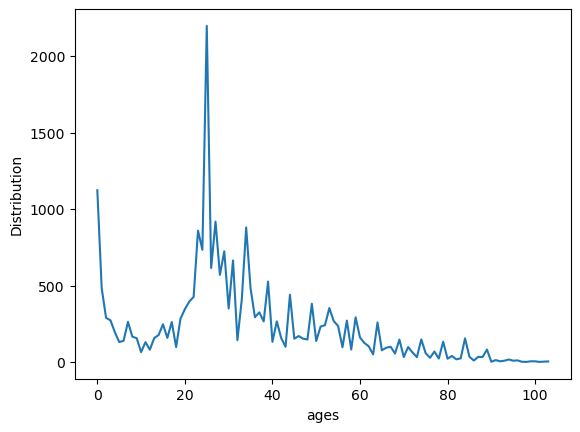

In [16]:
plt.plot(counts)
plt.xlabel('ages')
plt.ylabel('Distribution')
plt.show()

In [17]:
len(genders)

23708

Defining labels for Output

In [18]:
labels = []
i=0
while i<len(ages):
    label=[]
    label.append(ages[i])
    label.append(genders[i])
    labels.append(label)
    #to ensure loop doesn't go to infinity
    i=i+1

## Creating another list of images from existing one
 For better learning

In [19]:
images_f_2 = images_f/255

In [20]:
#(number of samples in total, dimensions of each image)
images_f_2.shape

(23708, 48, 48, 3)

In [21]:
labels_f = np.array(labels)

## Splitting the dataset into test and train

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train,X_test,Y_train,Y_test = train_test_split(images_f_2,labels_f,test_size=0.25)

In [24]:
Y_train[0:5]

array([[32,  1],
       [23,  1],
       [35,  0],
       [40,  0],
       [26,  1]])

# Splitting the 'Y_test' and 'Y_train' further 
for better understanding

In [25]:
Y_train_2 = [Y_train[:,1],Y_train[:,0]]
Y_test_2 = [Y_test[:,1],Y_test[:,0]]

In [26]:
#shows the genders
Y_train_2[0][0:5]

array([1, 1, 0, 0, 1])

In [27]:
Y_train_2[1][0:5]

array([32, 23, 35, 40, 26])

Defining the Model

In [28]:
def Convolution(input_tensor,filters):
    x = Conv2D(filters=filters,kernel_size=(3,3),padding="same",strides=(1,1),kernel_regularizer=l2(0.001))(input_tensor)
    x = Dropout(0.1)(x)
    x = Activation('relu')(x)
    return x

In [29]:
def model(input_shape):
    inputs = Input((input_shape))
    #define first layer as
    conv_1=Convolution(inputs,32)
    maxp_1=MaxPool2D(pool_size=(2,2))(conv_1)
    #define second layer as
    conv_2=Convolution(maxp_1,64)
    maxp_2=MaxPool2D(pool_size=(2,2))(conv_2)
    #define third one
    conv_3=Convolution(maxp_2,128)
    maxp_3=MaxPool2D(pool_size=(2,2))(conv_3)
    #define forth one
    conv_4=Convolution(maxp_3,256)
    maxp_4=MaxPool2D(pool_size=(2,2))(conv_4)
    flatten = Flatten()(maxp_4)
    dense_1 = Dense(64,activation='relu')(flatten)
    dense_2 = Dense(64,activation='relu')(flatten)
    drop_1=Dropout(0.2)(dense_1)
    drop_2=Dropout(0.2)(dense_2)
    output_1=Dense(1,activation='sigmoid',name='sex_out')(drop_1)
    output_2=Dense(1,activation='relu',name='age_out')(drop_2)
    model = Model(inputs=[inputs],outputs=[output_1,output_2])
    model.compile(loss=["binary_crossentropy","mae"],optimizer="Adam",metrics=["accuracy"])
    return model

In [30]:
Model=model((48,48,3))

In [31]:
Model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 48, 48, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 48, 48, 32)   896         ['input_1[0][0]']                
                                                                                                  
 dropout (Dropout)              (None, 48, 48, 32)   0           ['conv2d[0][0]']                 
                                                                                                  
 activation (Activation)        (None, 48, 48, 32)   0           ['dropout[0][0]']                
                                                                                              

In [32]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Initializing the model

In [33]:
fle_s='Age_Sex_Detection.h5'
checkpoint=ModelCheckpoint(fle_s,monitor='val_loss',verbose=1,save_best_only=True,save_weights_only=False,mode='auto',save_freq='epoch')
Early_stop=tf.keras.callbacks.EarlyStopping(patience=75,monitor='val_loss',restore_best_weights='True')
callback_list=[checkpoint,Early_stop]

## Running the model
## This may take much of your time

In [34]:
History=Model.fit(X_train,Y_train_2,batch_size=64,validation_data=(X_test,Y_test_2),epochs=250,callbacks=callback_list)

Epoch 1/250
278/278 [==============================] - ETA: 0s - loss: 17.0122 - sex_out_loss: 0.7001 - age_out_loss: 16.1349 - sex_out_accuracy: 0.5228 - age_out_accuracy: 0.0458
Epoch 1: val_loss improved from inf to 16.91111, saving model to Age_Sex_Detection.h5
278/278 [==============================] - 111s 384ms/step - loss: 17.0122 - sex_out_loss: 0.7001 - age_out_loss: 16.1349 - sex_out_accuracy: 0.5228 - age_out_accuracy: 0.0458 - val_loss: 16.9111 - val_sex_out_loss: 0.6925 - val_age_out_loss: 16.0538 - val_sex_out_accuracy: 0.5193 - val_age_out_accuracy: 0.0520
Epoch 2/250
278/278 [==============================] - ETA: 0s - loss: 13.5649 - sex_out_loss: 0.6912 - age_out_loss: 12.6872 - sex_out_accuracy: 0.5290 - age_out_accuracy: 0.0449
Epoch 2: val_loss improved from 16.91111 to 12.70018, saving model to Age_Sex_Detection.h5
278/278 [==============================] - 97s 348ms/step - loss: 13.5649 - sex_out_loss: 0.6912 - age_out_loss: 12.6872 - sex_out_accuracy: 0.5290 - 

Model Evaluation

In [35]:
Model.evaluate(X_test,Y_test_2)

186/186 [==============================] - 6s 33ms/step - loss: 7.2575 - sex_out_loss: 0.2431 - age_out_loss: 6.3312 - sex_out_accuracy: 0.8925 - age_out_accuracy: 0.0520


[7.257457256317139,
 0.2431325912475586,
 6.331199645996094,
 0.8925257325172424,
 0.05196557939052582]

In [36]:
pred = Model.predict(X_test)

186/186 [==============================] - 7s 33ms/step


In [37]:
pred[1]

array([[34.39057  ],
       [14.38747  ],
       [39.972836 ],
       ...,
       [46.63712  ],
       [41.60432  ],
       [ 1.2037637]], dtype=float32)

# Plotting loss

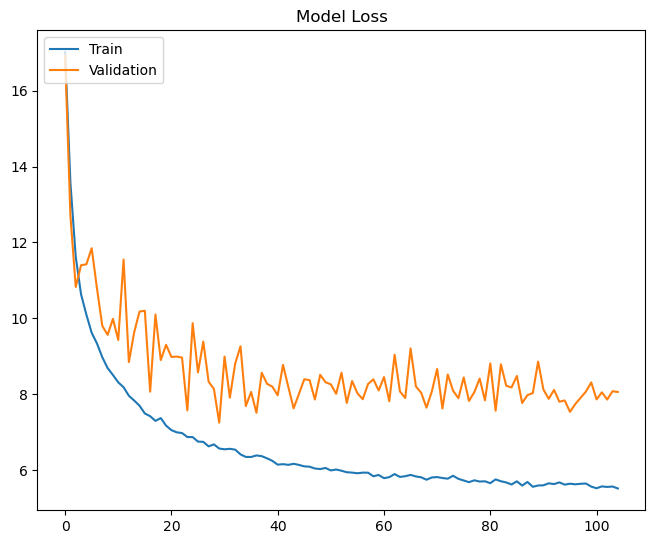

In [38]:
plt.plot(History.history['loss'])
plt.plot(History.history['val_loss'])
plt.title('Model Loss')
plt.xlabel=('Epoch')
plt.ylabel=('Loss')
plt.legend(['Train','Validation'],loc='upper left')
plt.subplots_adjust(top=1.0,bottom=0.0,right=0.95,left=0,hspace=0.25,wspace=0.35)

## Plotting sex accuracy

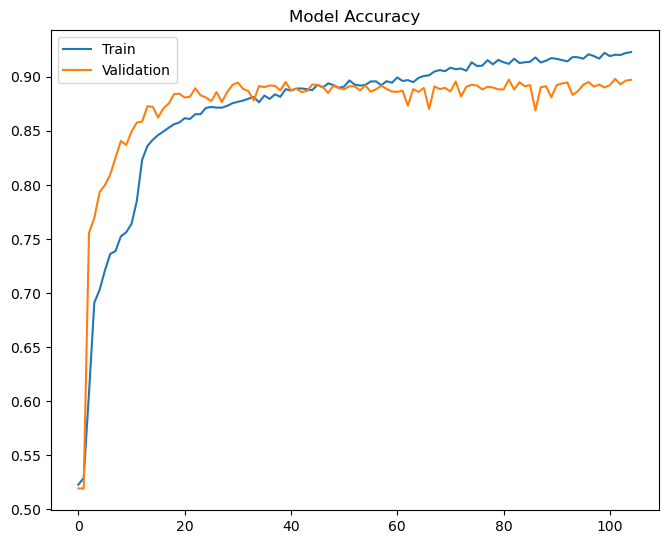

In [39]:
plt.plot(History.history['sex_out_accuracy'])
plt.plot(History.history['val_sex_out_accuracy'])
plt.title('Model Accuracy')
plt.xlabel=('Epoch')
plt.ylabel=('Accuracy')
plt.legend(['Train','Validation'],loc='upper left')
plt.subplots_adjust(top=1.0,bottom=0.0,right=0.95,left=0,hspace=0.25,wspace=0.35)

## Plotting Gender Accuracy

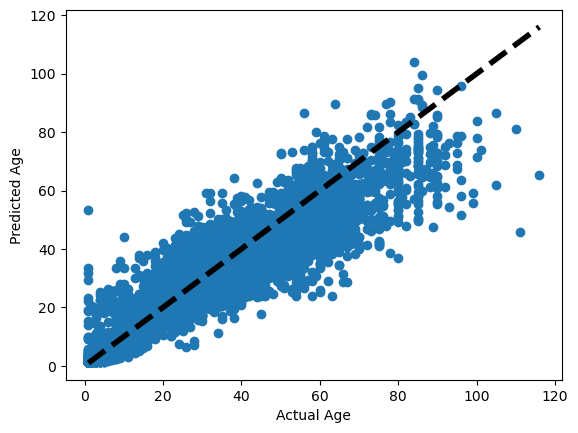

In [40]:
#Now we will do plot for age accuracy
fig,ax=plt.subplots()
ax.scatter(Y_test_2[1],pred[1])
ax.plot([Y_test_2[1].min(),Y_test_2[1].max()],[Y_test_2[1].min(),Y_test_2[1].max()],'k--',lw=4)
ax.set_xlabel('Actual Age')
ax.set_ylabel('Predicted Age')
plt.show()

# Making report of Model (Gender only)

In [53]:
i=0
Pred_l=[]
while(i<len(pred[0])):
    Pred_l.append(int(np.round(pred[0][i])))
    i=i+1

In [54]:
#Now import some library from sklearn
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [55]:
report = classification_report(Y_test_2[0],Pred_l)

In [56]:
#Precision in Male is 51% and Female is 0
print(report)

              precision    recall  f1-score   support

           0       0.92      0.87      0.89      3078
           1       0.87      0.92      0.89      2849

    accuracy                           0.89      5927
   macro avg       0.89      0.89      0.89      5927
weighted avg       0.89      0.89      0.89      5927



# Making Heatmap of the Model(Gender only)

In [57]:
results = confusion_matrix(Y_test_2[0],Pred_l)

<Axes: >

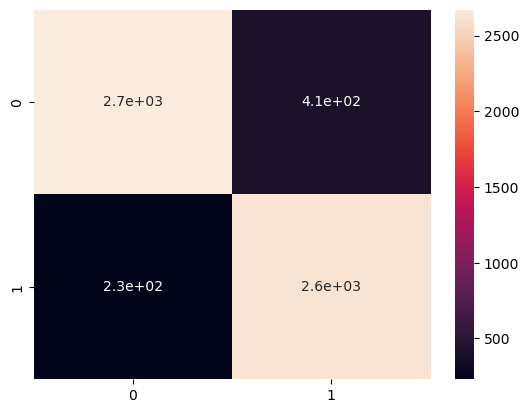

In [58]:
import seaborn as sns
sns.heatmap(results,annot=True)

# Testing images ourself

In [59]:
def test_image(ind,images_f,images_f_2,Model):
    plt.imshow(images_f[ind])
    image_test=images_f_2[ind]
    pred_l=Model.predict(np.array([image_test]))
    sex_f=['Male','Female']
    age=int(np.round(pred_l[1][0]))
    sex=int(np.round(pred_l[0][0]))
    print("Predicted Age is "+str(age))
    print("Predicted Gender is "+sex_f[sex])

# Test 1

1/1 [==============================] - 0s 227ms/step
Predicted Age is 84
Predicted Gender is Female


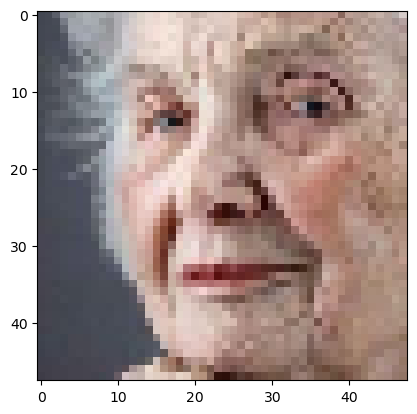

In [60]:
test_image(4,images_f,images_f_2,Model)

1/1 [==============================] - 0s 47ms/step
Predicted Age is 14
Predicted Gender is Male


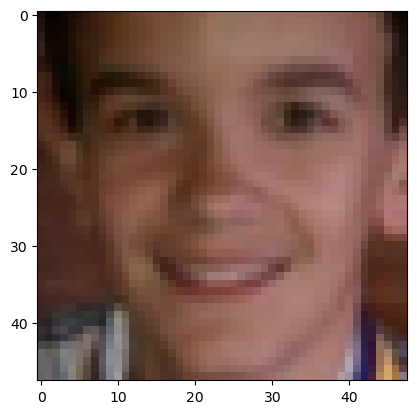

In [61]:
#Test 2
test_image(23,images_f,images_f_2,Model)

1/1 [==============================] - 0s 41ms/step
Predicted Age is 11
Predicted Gender is Female


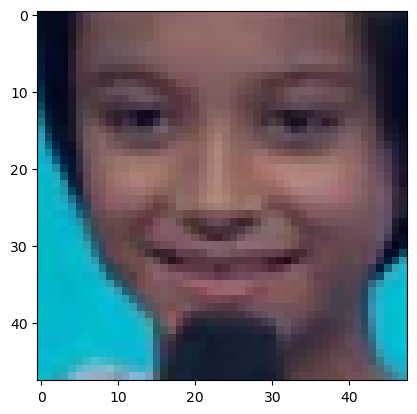

In [62]:
#Test 3
test_image(168,images_f,images_f_2,Model)

1/1 [==============================] - 0s 34ms/step
Predicted Age is 25
Predicted Gender is Male


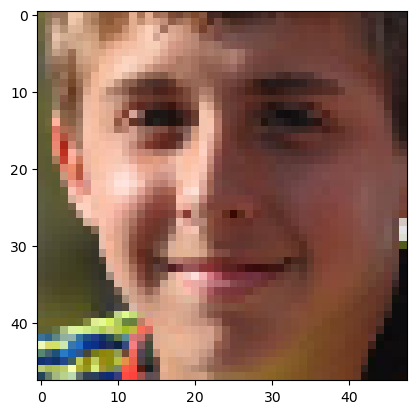

In [63]:
#Test 4
#Error in age in this Case
test_image(888,images_f,images_f_2,Model)

1/1 [==============================] - 0s 42ms/step
Predicted Age is 20
Predicted Gender is Female


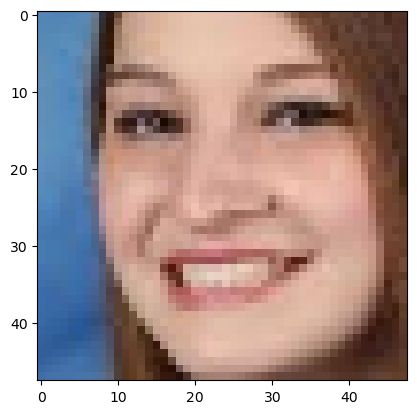

In [64]:
#Test 5
test_image(1288,images_f,images_f_2,Model)